In [1]:
import base64
import io
import json
import os
import re
import stringcase
import voxeloo
import numpy as np
from dataclasses import dataclass
from glob import glob
from string import Template
from typing import Dict
from PIL import Image

In [2]:
def to_hex(rgb):
    rgb = np.array(rgb, dtype=np.uint32)
    return np.array((rgb[..., 0] << 24) | (rgb[..., 1] << 16) | (rgb[..., 2] << 8) | 0xff)

In [3]:
def to_rgb(img):
    return np.stack(
        [
            (img >> 24) & 0xff,
            (img >> 16) & 0xff,
            (img >> 8) & 0xff
        ], 
        axis=-1,
    ).astype(np.uint8)

In [4]:
def encode_mrea(metalic, roughness, emissive, ao):
    m = np.uint32(255 * metalic)
    r = np.uint32(255 * roughness)
    e = np.uint32(255 * emissive)
    a = np.uint32(255 * ao)
    return (m << 24) | (r << 16) | (e << 8) | a

In [5]:
def unique_colors(img):
    return np.unique(to_hex(img))

In [6]:
def palette_swap(img, palette_map):
    src = to_hex(img)
    dst = to_hex(img)
    for s, d in palette_map.items():
        dst[src == s] = d
    return Image.fromarray(to_rgb(dst))

In [7]:
def show_large(img):
    display(img.resize((256, 256), Image.NEAREST))

In [109]:
OLD_NAME = "moonstone"
NEW_NAME = "moonstone"

In [110]:
PROJECT = "moon_and_sun"

In [111]:
IMAGES = [
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_black_v0_side.png",
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_black_v0_top.png",
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_black_v0_bottom.png",
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_white_v0_side.png",
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_white_v0_top.png",
    f"/home/taylor/art/{PROJECT}/{OLD_NAME}_white_v0_bottom.png",
]

In [112]:
{hex(color) for img in IMAGES for color in unique_colors(Image.open(img))}

{'0x93bbceff', '0xa3c6d6ff', '0xb6d7e5ff', '0xe0eef3ff'}

In [113]:
for color in {hex(color) for img in IMAGES for color in unique_colors(Image.open(img))}:
    print(color)

0x93bbceff
0xe0eef3ff
0xb6d7e5ff
0xa3c6d6ff


In [130]:
rgb_palette = {
    0x93bbceff: 0x93bbceff,
    0xe0eef3ff: 0xe0eef3ff,
    0xb6d7e5ff: 0xb6d7e5ff,
    0xa3c6d6ff: 0xa3c6d6ff,
}

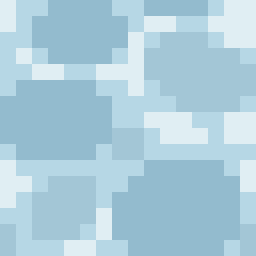

In [131]:
img = Image.open(IMAGES[0])
show_large(palette_swap(img, rgb_palette))
palette_swap(img, rgb_palette)

In [140]:
mrea_palette = {
    0x93bbceff: encode_mrea(0.5, 1.0, 0.15, 0.0),
    0xe0eef3ff: encode_mrea(0.5, 1.0, 0.15, 0.0),
    0xb6d7e5ff: encode_mrea(0.5, 1.0, 0.15, 0.0),
    0xa3c6d6ff: encode_mrea(0.5, 1.0, 0.15, 0.0),
}

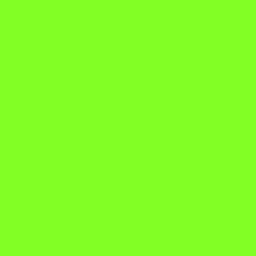

In [141]:
show_large(palette_swap(img, mrea_palette))

In [134]:
def to_mrea_name(name):
    return path[::-1].replace("_", "aerm_", 1)[::-1]

In [135]:
for path in IMAGES:
    #rgb = palette_swap(Image.open(path), rgb_palette)
    #rgb.save(path.replace(OLD_NAME, NEW_NAME))

    mrea = palette_swap(Image.open(path), mrea_palette)
    mrea.save(to_mrea_name(path).replace(OLD_NAME, NEW_NAME))

In [ ]:
rgb = Image.open("/home/taylor/art/flares/flare-v1.png")

In [ ]:
x = np.array(rgb)[:24, :24, :]

mask = (x[..., 0] == 255) & (x[..., 1] == 255) & (x[..., 2] == 255)
x[mask, 3] = 0

Image.fromarray(x).save("/home/taylor/art/flares/flare-v1.png")

#show_large(Image.fromarray(x))